In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Cargar el archivo
df=pd.read_csv("C:/Users/angel/OneDrive/Escritorio/PersonalP/df.csv")
print(df.columns)


Index(['song_name', 'artist', 'popularity', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration'],
      dtype='object')


In [72]:

# Lista a excluir
exclude_artists = [ 
    "Rain Sounds",
    "Binaural Beats Sleep",
    "Thunderstorm Sound Bank",
    "Ocean Waves For Sleep",
    "Image Sounds",
    "Shun Yu",
    "Ron Komie",
    "Samson Oxmoor",
    "Yuuki Sung",
    "Mike Smith",
    "DJ Fuqua",
    "Armin van Buuren"
]

df = df[~df["artist"].isin(exclude_artists)]

df.to_csv("C:/Users/angel/OneDrive/Escritorio/PersonalP/df.csv", index=False)

print("Filas restantes:", len(df))

print(df["artist"].value_counts().head(50))


Filas restantes: 220530
artist
Johann Sebastian Bach          3621
Wolfgang Amadeus Mozart        1756
Ludwig van Beethoven            928
Frédéric Chopin                 614
Claude Debussy                  451
Waka Flocka Flame               276
Los Cadetes De Linares          266
Antonio Vivaldi                 254
Duo Libano                      240
Above & Beyond                  240
George Jones                    215
The Beatles                     173
Pyotr Ilyich Tchaikovsky        164
my little airport               163
Franz Schubert                  139
Neil Diamond                    136
BTS                             133
Elvis Presley                   131
George Frideric Handel          128
Queen                           127
Eagles                          125
Håkan Hellström                 122
Chief Keef                      122
Glee Cast                       118
Scooter                         118
Vybz Kartel                     117
Hank Williams                   1

In [73]:
# Obtener los 5 artistas con más canciones
top5_artists = df["artist"].value_counts().head(5)

# Filtrar solo las canciones de esos artistas
df_top5 = df[df["artist"].isin(top5_artists)]

# Ordenar por artista y luego por nombre de canción (song_name)
df_top5_sorted = df_top5.sort_values(by=["artist", "song_name"])

# Guardar solo la columna song_name y artist en CSV
df_top5_sorted[["artist", "song_name"]].to_csv("test.csv", index=False)

print("Archivo 'test.csv' generado con canciones de los 5 artistas con más canciones.")

Archivo 'test.csv' generado con canciones de los 5 artistas con más canciones.


                                           song_name           artist  \
0                                           Pangarap  Barbie's Cradle   
1                                       I Feel Alive    Steady Rollin   
2                                             Poison   Bell Biv DeVoe   
3  Baby It's Cold Outside (feat. Christina Aguilera)      CeeLo Green   
4                                         Dumb Litty             KARD   

   popularity  danceability  energy  key  loudness  mode  speechiness  \
0        41.0         0.682   0.401    2   -10.068     1       0.0236   
1        28.0         0.303   0.880    9    -4.739     1       0.0442   
2         0.0         0.845   0.652    6    -7.504     0       0.2160   
3        41.0         0.425   0.378    5    -5.819     0       0.0341   
4        65.0         0.760   0.887    9    -1.993     1       0.0409   

   acousticness  instrumentalness  liveness  valence    tempo  duration  
0       0.27900           0.01170    0.0887    0

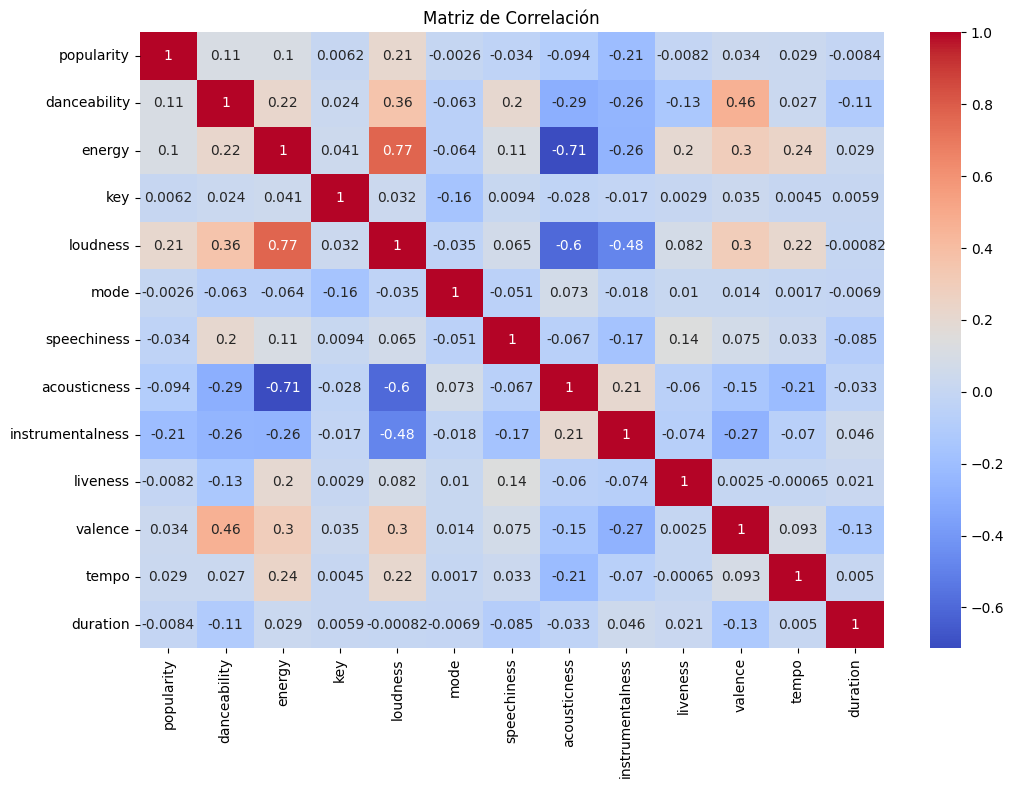

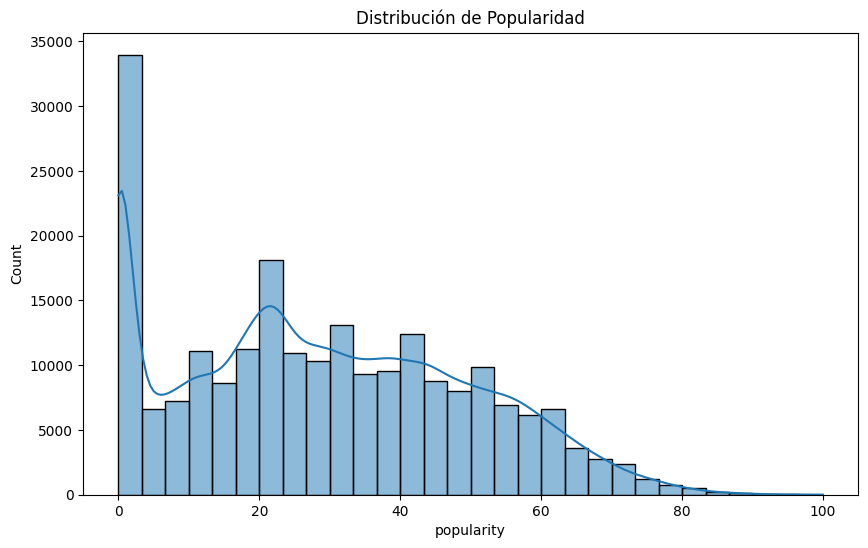

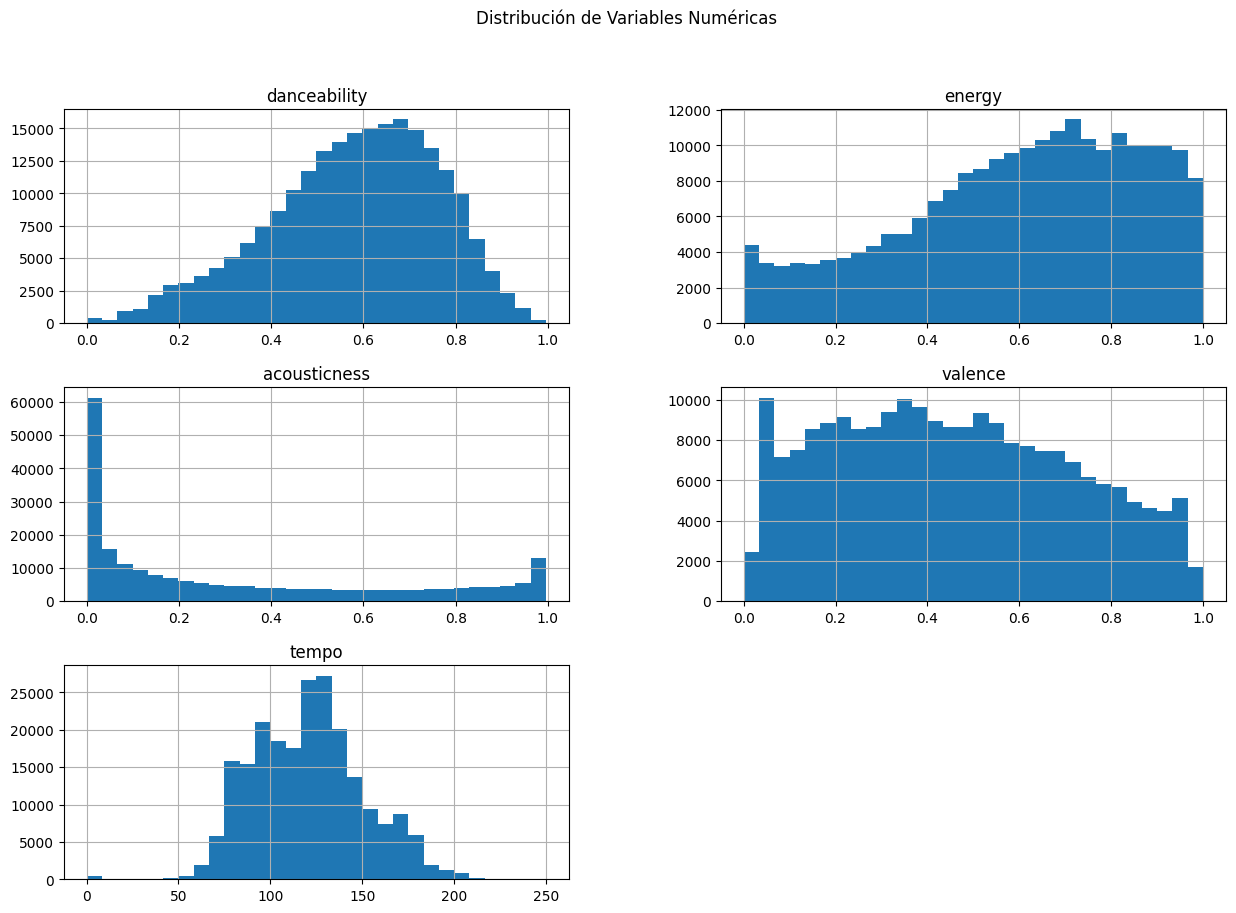

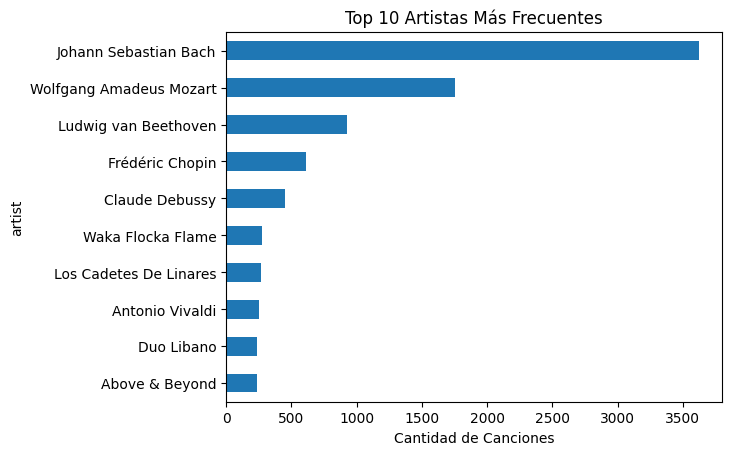

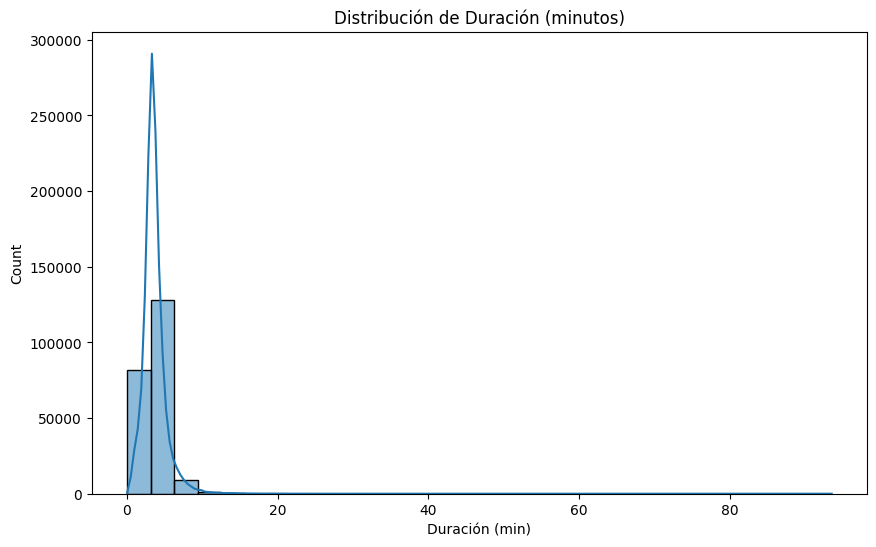

In [74]:
### Análisis Inicial

# Ver primeras filas
print(df.head())

# Estadísticas descriptivas
print(df.describe())

# Correlación entre features numéricos
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

# Distribución de popularidad
plt.figure(figsize=(10, 6))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title('Distribución de Popularidad')
plt.show()

# Distribución de variables numéricas
cols=["danceability","energy","acousticness","valence","tempo"]
df[cols].hist(bins=30, figsize=(15,10))
plt.suptitle("Distribución de Variables Numéricas")
plt.show()

# Artistas más frecuentes
df["artist"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Artistas Más Frecuentes")
plt.xlabel("Cantidad de Canciones")
plt.gca().invert_yaxis()
plt.show()

# Duración de canciones
df["duration_min"] = df["duration"]/60000
plt.figure(figsize=(10,6))
sns.histplot(df["duration_min"], bins=30, kde=True)
plt.title("Distribución de Duración (minutos)")
plt.xlabel("Duración (min)")
plt.show()

In [83]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Features a usar
feature_cols = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
                'instrumentalness', 'liveness', 'valence', 'tempo', 'duration']

# Escalar
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[feature_cols])

# Función principal
def recommend_songs_interactive(query, n=10):
    # Buscar canciones que contengan el string
    matches = df[df['song_name'].str.lower().str.contains(query.lower())]
    if matches.empty:
        print(f"No se encontraron canciones que contengan: '{query}'")
        return
    
    # Mostrar opciones
    print(f"Se encontraron {len(matches)} canciones que contienen '{query}':\n")
    for i, (idx, row) in enumerate(matches.iterrows()):
        print(f"{i+1}. {row['song_name']} - {row['artist']}")
    
    # Pedir selección
    try:
        choice = int(input("\nElige el número de la canción que quieres usar: ")) - 1
        if choice < 0 or choice >= len(matches):
            print("Selección inválida.")
            return
    except ValueError:
        print("Entrada no válida.")
        return

    selected_index = matches.index[choice]
    selected_name = df.loc[selected_index, 'song_name']
    print(f"\nRecomendando canciones similares a: {selected_name} - {df.loc[selected_index, 'artist']}\n")

    # Vector objetivo
    target_vector = scaled_features[selected_index].reshape(1, -1)
    similarities = cosine_similarity(target_vector, scaled_features)[0]

    sim_scores = list(enumerate(similarities))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != selected_index]

    top_indices = [i[0] for i in sim_scores[:n]]

    recommendations = df.iloc[top_indices][['song_name', 'artist', 'popularity']].copy()
    recommendations['similarity'] = [sim_scores[i][1] for i in range(n)]

    print(recommendations)
    return recommendations

# Ejemplo
recommend_songs_interactive("Enemy", n=10)


Se encontraron 59 canciones que contienen 'Enemy':

1. Enemy Turf - Juvenile
2. Under Enemy Arms - Trippie Redd
3. My Own Worst Enemy - Lit
4. My Enemy - Cold California
5. Enemy - From Ashes to New
6. Enemy - Saito
7. Enemy (Gydra Remix) - Instrumental - Blue Stahli
8. So This Is Where The Enemy Sleeps? (Radio Friendly Edit) - The Fight Song
9. Crush the Enemy - J-Dawg
10. Enemy - Red Shahan
11. Unknown Enemy - Kay
12. Worst Enemy - Isaiah
13. Enemy - Jared Evan
14. Enemy - Noyz Narcos
15. Biggest Enemy - And Then Came Fall
16. Worst Enemy - Tunnel Vision
17. Enemy - Nerv
18. ENEMY - Diskord
19. Enemy - Live Through Death
20. Enemy of the Matrix - Lilou & John
21. Enemy - Muscadine Bloodline
22. Enemy - TheHxliday
23. Enemy - Iamjakehill
24. Enemy - Beartooth
25. Enemy - Oliver Tree
26. My Enemy - CHVRCHES
27. Public Enemy - Adam Calhoun
28. Public Enemy - Yellow Claw
29. The Enemy - Andrew Belle
30. Water No Get Enemy - Fela Kuti
31. Water No Get Enemy - Voilaaa;Pat Kalla
32. Enemy -

,song_name,artist,popularity,similarity
120126,Stay,Tamia,28.0,0.980260
135420,Sounds Like Help,Austin Basham,50.0,0.978552
54619,Backwards,LAUNDRY DAY,26.0,0.974290
29073,The Face Of God,Camp Cope,37.0,0.969364
30394,Annie,Olivver the Kid,32.0,0.968828
109596,Give You Up,Dido,59.0,0.968735
42442,A Love Song Seven Ways,Benjamin Lazar Davis,13.0,0.963018
23076,Yours,Home Free,41.0,0.962396
172017,Tid tröste,Mando Diao,29.0,0.959765
13626,Jubel - Radio Edit,Klingande,52.0,0.957717
